# **Análisis de los factores asociados al desempeño en las pruebas Saber 11: Un estudio comparativo entre Bogotá D.C. y el departamento del Chocó**

## **Coleccion y Descripcion de los Datos**

**Importar liberias**
Se importaron las librerías necesarias para el análisis de datos, incluyendo herramientas de manipulación (pandas, numpy), visualización (matplotlib, seaborn) y procesamiento distribuido (PySpark).

In [2]:
#se importan las librerias necesarias
import requests as request
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import findspark

ModuleNotFoundError: No module named 'findspark'

In [2]:
!pip install findspark

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


**Apache Spark**
Se inicializó findspark para integrar Apache Spark en el entorno de Python. Luego, se configuró la sesión de Spark mediante SparkConf y SparkSession, definiendo parámetros como el modo de ejecución, la asignación de recursos y la conexión al clúster.

In [3]:
findspark.init()
from pyspark import SparkContext, SparkConf  #---> Contexto y configuración de Pyspark
from pyspark.sql import SparkSession         #---> Sesión para entorno de consultas SQL

In [4]:
# se requiere levantar la sesion para trabajar con los servicios
configura = SparkConf()
configura.set("spark.scheduler.mode", "FAIR")
configura.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
configura.setMaster("spark://10.43.97.171:7077")
configura.setAppName("Stroke_MejiaSPARK")
sparkMejia=SparkSession.builder.config(conf=configura).getOrCreate()
sparkMejia

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/09 16:31:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## **Exploracion de Datos**


Se crean dos objetos por cada conjunto de datos: uno de tipo PySpark y otro de tipo Pandas, con el fin de aprovechar las ventajas de cada herramienta en diferentes etapas del análisis. El objeto en PySpark se utiliza para realizar operaciones de filtrado, transformación y agregación de manera eficiente en entornos distribuidos. Mientras que, el objeto en Pandas se emplea para la visualización y análisis exploratorio.

In [5]:
from pyspark.sql import functions as F

In [ ]:
df1Py00 = sparkMejia.read.csv("data\MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260407.csv", header=True, inferSchema=True)

In [ ]:
df2Py00 = sparkMejia.read.format("csv").option("header","true").load("data\ICFES Bog y Choco.csv", sep=";")

In [4]:
df1Pd00 = pd.read_csv("data\MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260407.csv")

In [5]:
df2Pd00 = pd.read_csv("data\ICFES Bog y Choco.csv", sep=";")

## Estadísticas en Educación por Municipio

In [10]:
df1Py00.show(1)

26/04/09 16:31:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----+----------------+------------+-------------------+------------+----------+------------------+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
| AÑO|CÓDIGO_MUNICIPIO|   MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|               ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTUR

In [13]:
df2Pd00.head(3)

,periodo,estu_consecutivo,estu_estudiante,estu_tipodocumento,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,...,percentil_ingles,percentil_lectura_critica,percentil_matematicas,percentil_sociales_ciudadanas,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas
0,20232,SB11202340274007,ESTUDIANTE,CC,URBANO,N,A,ACADÉMICO,"3,11769E+11","3,11769E+11",...,16.0,47,56,65,56,263,39.0,52,54,53
1,20232,SB11202340273654,ESTUDIANTE,TI,URBANO,N,A,ACADÉMICO,"3,11769E+11","3,11769E+11",...,85.0,63,9,66,53,254,64.0,57,35,54
2,20232,SB11202340274043,ESTUDIANTE,TI,URBANO,N,A,ACADÉMICO,"3,11769E+11","3,11769E+11",...,23.0,14,27,26,43,210,42.0,41,44,40


In [14]:
# Funcion para limpiar y convertir porcentajes str a float
def clean_percentage(s):
    if isinstance(s, str):
        return float(s.replace('%', '').replace(',', '.')) if s else None
    return s

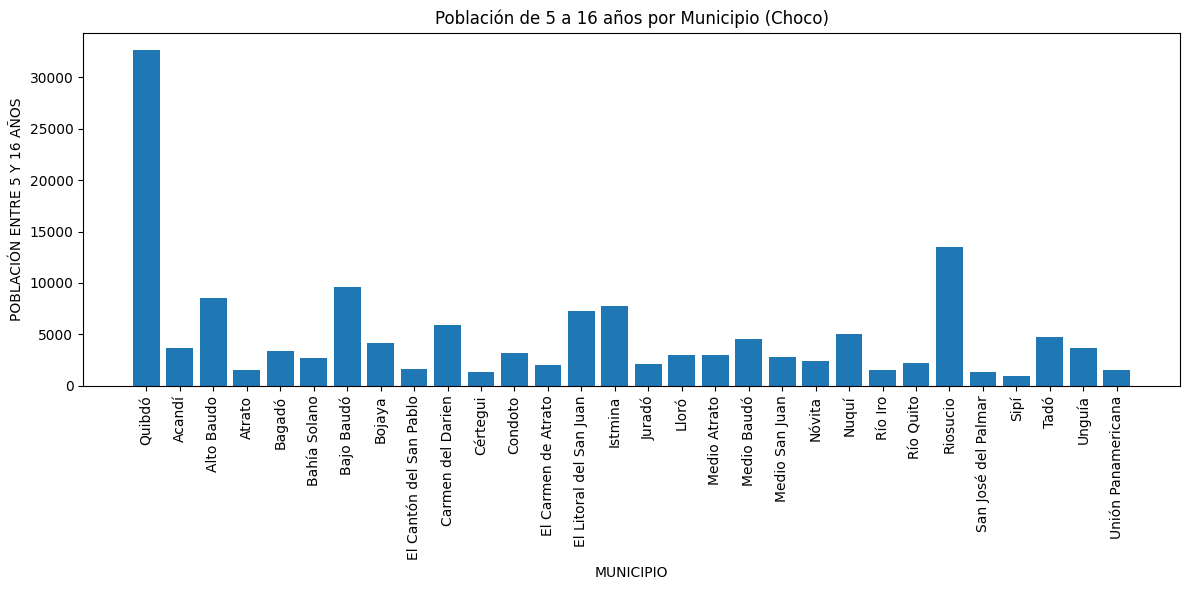

In [15]:
df1Pd00_filtered = df1Pd00[df1Pd00['CÓDIGO_DEPARTAMENTO'] == 27] # filtrar los municipios que pertenecen a Choco 
plt.figure(figsize=(12, 6)) 
plt.bar(df1Pd00_filtered['MUNICIPIO'], 
        df1Pd00_filtered['POBLACIÓN_5_16']) 
plt.xlabel('MUNICIPIO') 
plt.ylabel('POBLACIÓN ENTRE 5 Y 16 AÑOS') 
plt.title('Población de 5 a 16 años por Municipio (Choco)') 
plt.xticks(rotation=90) 
plt.tight_layout() 
plt.show()

In [16]:
df1Pd00['TASA_MATRICULACIÓN_5_16'] = df1Pd00['TASA_MATRICULACIÓN_5_16'].apply(clean_percentage)
#se calcula el promedio ponderado
weighted_average = df1Pd00.groupby("DEPARTAMENTO").apply(
    lambda x: (x["TASA_MATRICULACIÓN_5_16"] * x["POBLACIÓN_5_16"]).sum() / x["POBLACIÓN_5_16"].sum()
)

print(weighted_average)

DEPARTAMENTO
Bogotá, D.C.    92.90000
Chocó           84.91272
dtype: float64


/tmp/ipykernel_3200581/3749734230.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_average = df1Pd00.groupby("DEPARTAMENTO").apply(


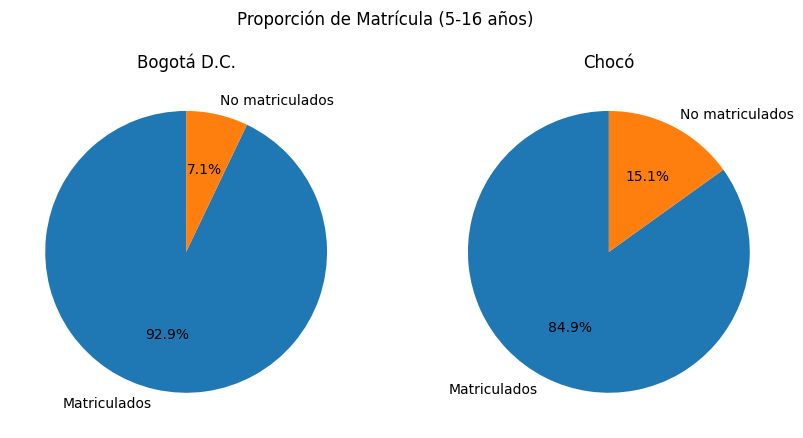

In [17]:
# Valores
bogota = weighted_average["Bogotá, D.C."]
choco = weighted_average["Chocó"]

# Crear figura con dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(10,5))

# Bogotá
axs[0].pie(
    [bogota, 100 - bogota],
    labels=["Matriculados", "No matriculados"],
    autopct='%1.1f%%',
    startangle=90
)
axs[0].set_title("Bogotá D.C.")

# Chocó
axs[1].pie(
    [choco, 100 - choco],
    labels=["Matriculados", "No matriculados"],
    autopct='%1.1f%%',
    startangle=90
)
axs[1].set_title("Chocó")

plt.suptitle("Proporción de Matrícula (5-16 años)")
plt.show()

Bogotá tiene mayor cobertura efectiva de matrícula
Chocó está por debajo, lo que sugiere menor acceso relativo

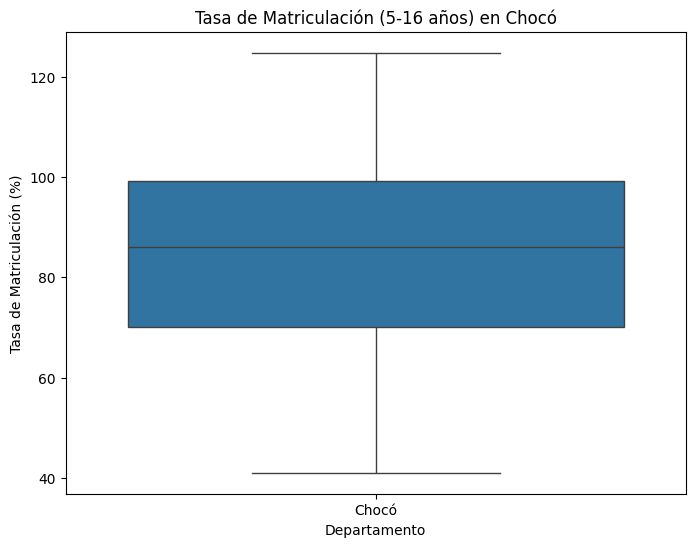

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df1Pd00[df1Pd00['DEPARTAMENTO'] == "Chocó"],
    x="DEPARTAMENTO",
    y="TASA_MATRICULACIÓN_5_16"
)

plt.title("Tasa de Matriculación (5-16 años) en Chocó")
plt.xlabel("Departamento")
plt.ylabel("Tasa de Matriculación (%)")

plt.show()

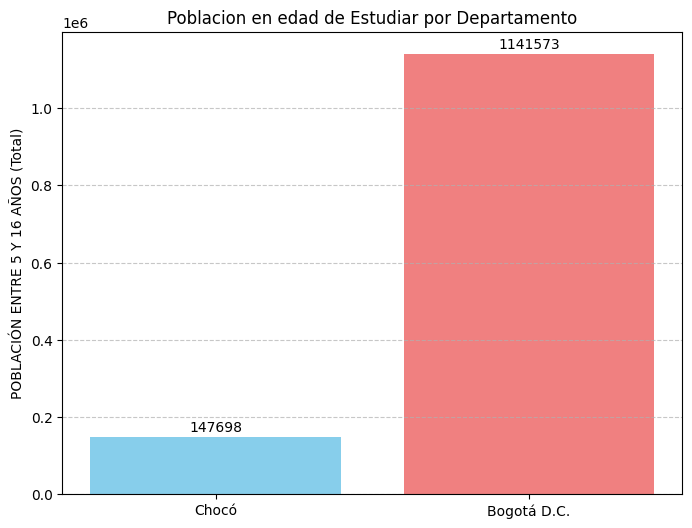

In [19]:
# Sumar la poblacion total entre 5 y 16 años del choco
sum_dep_choco = df1Pd00[df1Pd00['CÓDIGO_DEPARTAMENTO'] == 27]['POBLACIÓN_5_16'].sum()

# Sumar la poblacion total entre 5 y 16 años de bogota
sum_dep_bog = df1Pd00[df1Pd00['CÓDIGO_DEPARTAMENTO'] == 11]['POBLACIÓN_5_16'].sum()

# Data for the bar chart
departments = ['Chocó', 'Bogotá D.C.']
populations = [sum_dep_choco, sum_dep_bog]

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(departments, populations, color=['skyblue', 'lightcoral'])
plt.ylabel('POBLACIÓN ENTRE 5 Y 16 AÑOS (Total)')
plt.title('Poblacion en edad de Estudiar por Departamento')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5000, round(yval), ha='center', va='bottom') # Added 5000 for a small offset

plt.show()

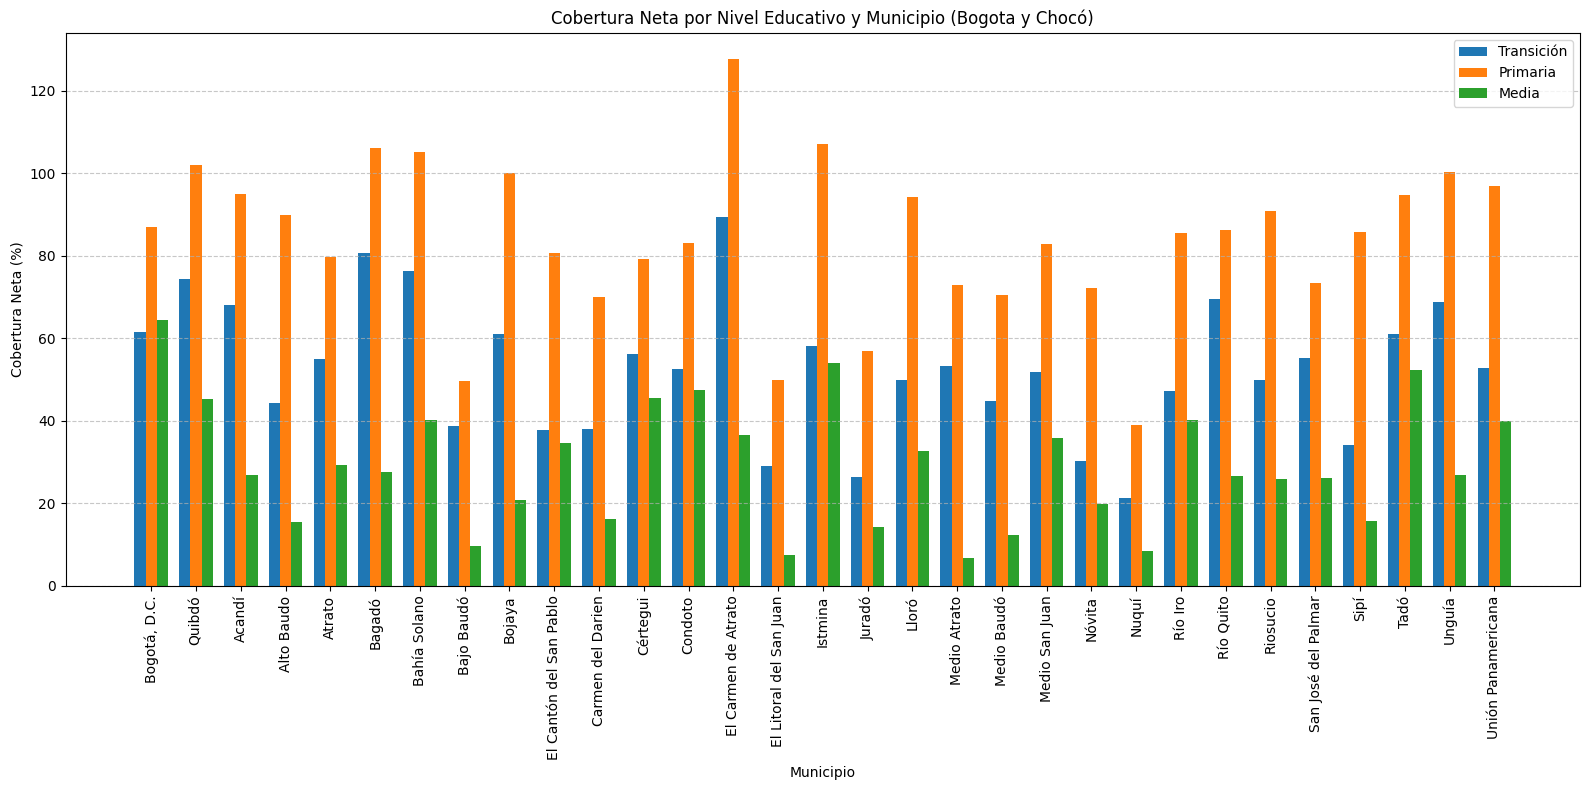

In [20]:
# Se aplica la funcion de limpieza para los porcentajes
df1Pd00['COBERTURA_NETA_TRANSICIÓN_NUM'] = df1Pd00['COBERTURA_NETA_TRANSICIÓN'].apply(clean_percentage)
df1Pd00['COBERTURA_NETA_PRIMARIA_NUM'] = df1Pd00['COBERTURA_NETA_PRIMARIA'].apply(clean_percentage)
df1Pd00['COBERTURA_NETA_MEDIA_NUM'] = df1Pd00['COBERTURA_NETA_MEDIA'].apply(clean_percentage)

# Posicion barras
bar_width = 0.25
index = range(len(df1Pd00['MUNICIPIO']))

plt.figure(figsize=(16, 8))

plt.bar([i - bar_width for i in index], df1Pd00['COBERTURA_NETA_TRANSICIÓN_NUM'], bar_width, label='Transición')
plt.bar(index, df1Pd00['COBERTURA_NETA_PRIMARIA_NUM'], bar_width, label='Primaria')
plt.bar([i + bar_width for i in index], df1Pd00['COBERTURA_NETA_MEDIA_NUM'], bar_width, label='Media')

plt.xlabel('Municipio')
plt.ylabel('Cobertura Neta (%)')
plt.title('Cobertura Neta por Nivel Educativo y Municipio (Bogota y Chocó)')
plt.xticks(index, df1Pd00['MUNICIPIO'], rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Respuestas Saber 11 Bogotá y Chocó Calendario A

In [21]:
df2Py00.show(1)

[Stage 4:>                                                          (0 + 1) / 1]

+-------+----------------+---------------+------------------+-------------------+-------------+---------------+-------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+------------------+-------------+----------------------+------------------+--------------------------+-------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+----------------------------+-----------------------+-----------------+-----------------+----------+--------------------+-----------+----------+-----------------------+--------------------+-----------------------+-----------------+-----------------+------------------------+-------------------+----------------+---------------------+-----------+---------------------

In [22]:
df2Py00.columns

['periodo',
 'estu_consecutivo',
 'estu_estudiante',
 'estu_tipodocumento',
 'cole_area_ubicacion',
 'cole_bilingue',
 'cole_calendario',
 'cole_caracter',
 'cole_cod_dane_establecimiento',
 'cole_cod_dane_sede',
 'cole_cod_depto_ubicacion',
 'cole_cod_mcpio_ubicacion',
 'cole_codigo_icfes',
 'cole_depto_ubicacion',
 'cole_genero',
 'cole_jornada',
 'cole_mcpio_ubicacion',
 'cole_naturaleza',
 'cole_nombre_establecimiento',
 'cole_nombre_sede',
 'cole_sede_principal',
 'desemp_c_naturales',
 'desemp_ingles',
 'desemp_lectura_critica',
 'desemp_matematicas',
 'desemp_sociales_ciudadanas',
 'estu_agregado',
 'estu_cod_depto_presentacion',
 'estu_cod_mcpio_presentacion',
 'estu_cod_reside_depto',
 'estu_cod_reside_mcpio',
 'estu_dedicacioninternet',
 'estu_dedicacionlecturadiaria',
 'estu_depto_presentacion',
 'estu_depto_reside',
 'estu_discapacidad',
 'estu_etnia',
 'estu_fechanacimiento',
 'estu_genero',
 'estu_grado',
 'estu_horassemanatrabaja',
 'estu_inse_individual',
 'estu_mcpio_p

In [23]:
df2Pd00.groupby("cole_depto_ubicacion")["punt_global"].describe()

,count,mean,std,min,25%,50%,75%,max
cole_depto_ubicacion,,,,,,,,
BOGOTÁ,79596.0,269.566360,49.225029,22.0,233.0,269.0,305.0,500.0
CHOCO,5366.0,209.082557,41.704665,108.0,178.0,200.0,232.0,414.0


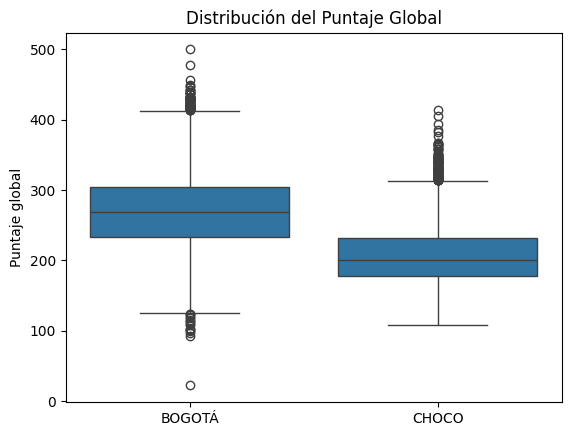

In [24]:
sns.boxplot(
    data=df2Pd00,
    x="cole_depto_ubicacion",
    y="punt_global"
)
plt.title("Distribución del Puntaje Global")
plt.xlabel("")
plt.ylabel("Puntaje global")
plt.show()

In [25]:
areas = ["punt_lectura_critica", "punt_matematicas", "punt_c_naturales", "punt_sociales_ciudadanas"]

prom_areas=df2Pd00.groupby("cole_depto_ubicacion")[areas].mean()
print(prom_areas)

                      punt_lectura_critica  punt_matematicas  \
cole_depto_ubicacion                                           
BOGOTÁ                           56.116476         54.359691   
CHOCO                            44.939993         41.403280   

                      punt_c_naturales  punt_sociales_ciudadanas  
cole_depto_ubicacion                                              
BOGOTÁ                       52.662508                 51.805870  
CHOCO                        41.012113                 39.793515  


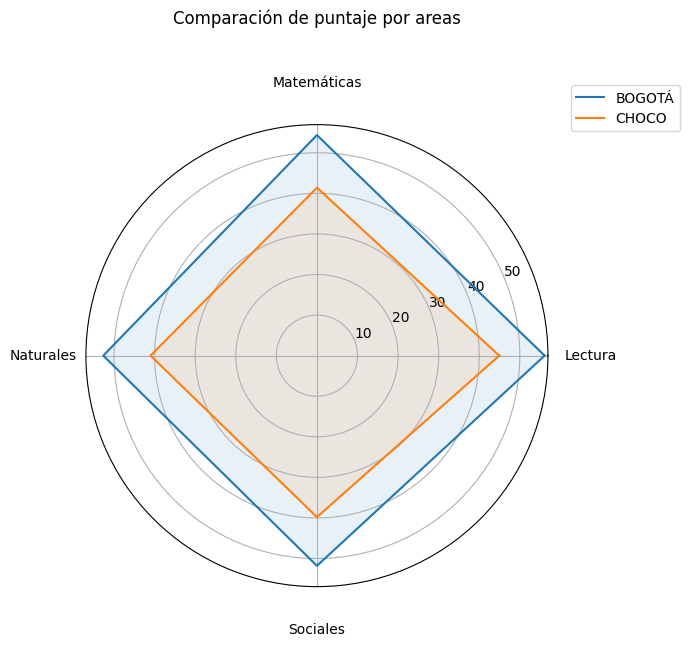

In [26]:
labels = ["Lectura", "Matemáticas", "Naturales", "Sociales"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for depto in prom_areas.index:
    values = prom_areas.loc[depto].values
    values = np.append(values, values[0])
    ang = np.append(angles, angles[0])
    ax.plot(ang, values, label=depto)
    ax.fill(ang, values, alpha=0.1)

ax.set_xticks(angles)
ax.set_xticklabels(labels)

# separación
ax.tick_params(axis='x', pad=20)

# rotación inteligente
for label, angle in zip(ax.get_xticklabels(), angles):
    label.set_rotation(np.degrees(angle))
    label.set_horizontalalignment('center')

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Comparación de puntaje por areas", y=1.2)
plt.show()

In [27]:
df2Py00.groupby(['fami_estratovivienda']).count().show()

[Stage 5:====================================================>    (11 + 1) / 12]

+--------------------+-----+
|fami_estratovivienda|count|
+--------------------+-----+
|           Estrato 3|28174|
|                NULL| 5866|
|           Estrato 2|32014|
|           Estrato 6|  612|
|           Estrato 4| 6448|
|         Sin Estrato| 1384|
|           Estrato 1| 9046|
|           Estrato 5| 1418|
+--------------------+-----+



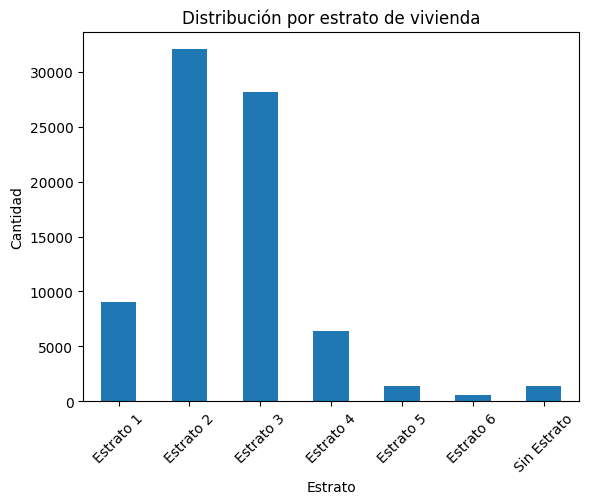

In [28]:
df_plot = df2Pd00.groupby('fami_estratovivienda').size()
df_plot.plot(
    kind='bar',
    x='fami_estratovivienda',
    y='count'
)

plt.title('Distribución por estrato de vivienda')
plt.ylabel('Cantidad')
plt.xlabel('Estrato')
plt.xticks(rotation=45)
plt.show()

## **Reporte de Calidad**

## Estadísticas en Educación por Municipio

In [29]:
df1Py00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df1Py00.columns]).show()

+---+----------------+---------+-------------------+------------+----------+---+--------------+-----------------------+--------------+-------------------------+-----------------------+-------------------------+--------------------+---------------+--------------------------+------------------------+--------------------------+---------------------+------------------------+---------------------------+---------+--------------------+------------------+--------------------+---------------+----------+---------------------+-------------------+---------------------+----------------+-----------+----------------------+--------------------+----------------------+-----------------+----------+---------------------+-------------------+---------------------+----------------+
|AÑO|CÓDIGO_MUNICIPIO|MUNICIPIO|CÓDIGO_DEPARTAMENTO|DEPARTAMENTO|CÓDIGO_ETC|ETC|POBLACIÓN_5_16|TASA_MATRICULACIÓN_5_16|COBERTURA_NETA|COBERTURA_NETA_TRANSICIÓN|COBERTURA_NETA_PRIMARIA|COBERTURA_NETA_SECUNDARIA|COBERTURA_NETA_MEDIA

In [30]:
print(f"SEDES_CONECTADAS_A_INTERNET")
print(f"Cantidad total de registros {df1Py00.count()}")
print(f"Cantidad procentaje registros nulos {31*100/df1Py00.count()} %")

SEDES_CONECTADAS_A_INTERNET
Cantidad total de registros 31
Cantidad procentaje registros nulos 100.0 %


In [31]:
print(f"TAMAÑO_PROMEDIO_DE_GRUPO")
print(f"Cantidad total de registros {df1Py00.count()}")
print(f"Cantidad procentaje registros nulos {31*100/df1Py00.count()} %")

TAMAÑO_PROMEDIO_DE_GRUPO
Cantidad total de registros 31
Cantidad procentaje registros nulos 100.0 %


In [6]:
resumen = df1Pd00.dtypes.to_frame(name='tipo')
resumen['nulos'] = df1Pd00.isnull().sum()
resumen['%_nulos'] = df1Pd00.isnull().mean() * 100

resumen

,tipo,nulos,%_nulos
AÑO,int64,0,0.0
CÓDIGO_MUNICIPIO,int64,0,0.0
MUNICIPIO,object,0,0.0
CÓDIGO_DEPARTAMENTO,int64,0,0.0
DEPARTAMENTO,object,0,0.0
CÓDIGO_ETC,int64,0,0.0
ETC,object,0,0.0
POBLACIÓN_5_16,int64,0,0.0
TASA_MATRICULACIÓN_5_16,object,0,0.0
COBERTURA_NETA,object,0,0.0


## Respuestas Saber 11 Bogotá y Chocó Calendario A

In [32]:
df2Py00.select([
    F.count(F.when(F.col(c).isNull() | F.isnan(c), c)).alias(c)
    for c in df2Py00.columns
]).show()

[Stage 23:==============================================>         (10 + 2) / 12]

+-------+----------------+---------------+------------------+-------------------+-------------+---------------+-------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+----------------+-------------------+------------------+-------------+----------------------+------------------+--------------------------+-------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+----------------------------+-----------------------+-----------------+-----------------+----------+--------------------+-----------+----------+-----------------------+--------------------+-----------------------+-----------------+-----------------+------------------------+-------------------+----------------+---------------------+-----------+---------------------+---

In [7]:
resumen = df2Pd00.dtypes.to_frame(name='tipo')
resumen['nulos'] = df2Pd00.isnull().sum()
resumen['%_nulos'] = df2Pd00.isnull().mean() * 100
pd.set_option('display.max_rows', None)
resumen

,tipo,nulos,%_nulos
periodo,int64,0,0.000000
estu_consecutivo,object,0,0.000000
estu_estudiante,object,0,0.000000
estu_tipodocumento,object,0,0.000000
cole_area_ubicacion,object,0,0.000000
cole_bilingue,object,16362,19.258021
cole_calendario,object,0,0.000000
cole_caracter,object,3982,4.686801
cole_cod_dane_establecimiento,object,0,0.000000
cole_cod_dane_sede,object,0,0.000000


## **Limpieza de los datos**

## Estadísticas en Educación por Municipio

In [33]:
df1Py00.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- CÓDIGO_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- CÓDIGO_ETC: integer (nullable = true)
 |-- ETC: string (nullable = true)
 |-- POBLACIÓN_5_16: integer (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: string (nullable = true)
 |-- COBERTURA_NETA: string (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_NETA_MEDIA: string (nullable = true)
 |-- COBERTURA_BRUTA: string (nullable = true)
 |-- COBERTURA_BRUTA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_BRUTA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_BRUTA_MEDIA: string (nullable = true)
 |-- TAMAÑO_PROMEDIO_DE_GRUPO: string (nullable = true

### Eliminación de variables

In [34]:
df1Py01 = df1Py00
df1Py01 = df1Py01.drop("AÑO") # todos los registros son del mismo año
df1Py01 = df1Py01.drop("CÓDIGO_ETC", "ETC") # se va a trabajar solo con departamento y municipio
df1Py01 = df1Py01.drop("TAMAÑO_PROMEDIO_DE_GRUPO", "SEDES_CONECTADAS_A_INTERNET") # el 100% de los registros son nulos para estas dos variables
df1Py01 = df1Py01.drop("COBERTURA_BRUTA", "COBERTURA_BRUTA_TRANSICIÓN", "COBERTURA_BRUTA_PRIMARIA", "COBERTURA_BRUTA_SECUNDARIA", "COBERTURA_BRUTA_MEDIA") 
# se decide trabajar con la cobertura neta en lugar de bruta
# para las variables de desercion, aprobacion, reprobacion y repitencia se van a analizar de manera general, no por grado escolar
df1Py01 = df1Py01.drop("DESERCIÓN_TRANSICIÓN", "DESERCIÓN_PRIMARIA", "DESERCIÓN_SECUNDARIA", "DESERCIÓN_MEDIA") 
df1Py01 = df1Py01.drop("APROBACIÓN_TRANSICIÓN", "APROBACIÓN_PRIMARIA", "APROBACIÓN_SECUNDARIA", "APROBACIÓN_MEDIA")
df1Py01 = df1Py01.drop("REPROBACIÓN_TRANSICIÓN", "REPROBACIÓN_PRIMARIA", "REPROBACIÓN_SECUNDARIA", "REPROBACIÓN_MEDIA")
df1Py01 = df1Py01.drop("REPITENCIA_TRANSICIÓN", "REPITENCIA_PRIMARIA", "REPITENCIA_SECUNDARIA", "REPITENCIA_MEDIA")

### Tipo y coherencia de los datos

In [35]:
df1Py01.printSchema()

root
 |-- CÓDIGO_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- POBLACIÓN_5_16: integer (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: string (nullable = true)
 |-- COBERTURA_NETA: string (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: string (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: string (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: string (nullable = true)
 |-- COBERTURA_NETA_MEDIA: string (nullable = true)
 |-- DESERCIÓN: string (nullable = true)
 |-- APROBACIÓN: string (nullable = true)
 |-- REPROBACIÓN: string (nullable = true)
 |-- REPITENCIA: string (nullable = true)



In [36]:
col_porcentajes = [
    "TASA_MATRICULACIÓN_5_16",
    "COBERTURA_NETA",
    "COBERTURA_NETA_TRANSICIÓN",
    "COBERTURA_NETA_PRIMARIA",
    "COBERTURA_NETA_SECUNDARIA",
    "COBERTURA_NETA_MEDIA",
    "DESERCIÓN",
    "APROBACIÓN",
    "REPROBACIÓN",
    "REPITENCIA"
]
df1Py02 = df1Py01

In [37]:
for col in col_porcentajes:
    df1Py02 = df1Py02.withColumn(
        col,
        F.regexp_replace(F.col(col), "%", "").cast("double")
    )

In [38]:
df1Py02.printSchema()

root
 |-- CÓDIGO_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CÓDIGO_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- POBLACIÓN_5_16: integer (nullable = true)
 |-- TASA_MATRICULACIÓN_5_16: double (nullable = true)
 |-- COBERTURA_NETA: double (nullable = true)
 |-- COBERTURA_NETA_TRANSICIÓN: double (nullable = true)
 |-- COBERTURA_NETA_PRIMARIA: double (nullable = true)
 |-- COBERTURA_NETA_SECUNDARIA: double (nullable = true)
 |-- COBERTURA_NETA_MEDIA: double (nullable = true)
 |-- DESERCIÓN: double (nullable = true)
 |-- APROBACIÓN: double (nullable = true)
 |-- REPROBACIÓN: double (nullable = true)
 |-- REPITENCIA: double (nullable = true)



## Respuestas Saber 11 Bogotá y Chocó Calendario A

In [39]:
df2Py00.printSchema()

root
 |-- periodo: string (nullable = true)
 |-- estu_consecutivo: string (nullable = true)
 |-- estu_estudiante: string (nullable = true)
 |-- estu_tipodocumento: string (nullable = true)
 |-- cole_area_ubicacion: string (nullable = true)
 |-- cole_bilingue: string (nullable = true)
 |-- cole_calendario: string (nullable = true)
 |-- cole_caracter: string (nullable = true)
 |-- cole_cod_dane_establecimiento: string (nullable = true)
 |-- cole_cod_dane_sede: string (nullable = true)
 |-- cole_cod_depto_ubicacion: string (nullable = true)
 |-- cole_cod_mcpio_ubicacion: string (nullable = true)
 |-- cole_codigo_icfes: string (nullable = true)
 |-- cole_depto_ubicacion: string (nullable = true)
 |-- cole_genero: string (nullable = true)
 |-- cole_jornada: string (nullable = true)
 |-- cole_mcpio_ubicacion: string (nullable = true)
 |-- cole_naturaleza: string (nullable = true)
 |-- cole_nombre_establecimiento: string (nullable = true)
 |-- cole_nombre_sede: string (nullable = true)
 |-- c

### Eliminación de variables

In [40]:
#Eliminar variables que no se utilizan en el analisis como: tipo de documento, pais en que reside, periodo, etc.
df2Py01 = df2Py00
df2Py01 = df2Py01.drop("periodo")
df2Py01 = df2Py01.drop("estu_tipodocumento")
df2Py01 = df2Py01.drop("estu_pais_reside")
df2Py01 = df2Py01.drop("cole_cod_dane_sede")
df2Py01 = df2Py01.drop("cole_cod_dane_establecimiento")
df2Py01 = df2Py01.drop("cole_naturaleza")
df2Py01 = df2Py01.drop("estu_agregado")
df2Py01 = df2Py01.drop("fami_comecarnepescadohuevo")
df2Py01 = df2Py01.drop("fami_comecerealfrutoslegumbre")
df2Py01 = df2Py01.drop("fami_comelechederivados")
df2Py01 = df2Py01.drop("cole_caracter")
df2Py01 = df2Py01.drop("cole_codigo_icfes")
df2Py01 = df2Py01.drop("cole_nombre_establecimiento")
df2Py01 = df2Py01.drop("cole_nombre_sede")
df2Py01 = df2Py01.drop("cole_sede_principal")
df2Py01 = df2Py01.drop("estu_cod_depto_presentacion")
df2Py01 = df2Py01.drop("estu_cod_mcpio_presentacion")
df2Py01 = df2Py01.drop("cole_cod_depto_ubicacion")
df2Py01 = df2Py01.drop("cole_cod_mcpio_ubicacion")
df2Py01 = df2Py01.drop("cole_depto_ubicacion")
df2Py01 = df2Py01.drop("cole_mcpio_ubicacion")
df2Py01 = df2Py01.drop("estu_depto_presentacion")
df2Py01 = df2Py01.drop("estu_mcpio_presentacion")
df2Py01 = df2Py01.drop("estu_nse_establecimiento")

In [41]:
df2Py01_limpio = df2Py01

#Variables sociales no predecibles -> "No aplica"

df2Py01_limpio = df2Py01_limpio.fillna({
    'fami_educacionmadre': 'No aplica',
    'fami_educacionpadre': 'No aplica',
    'fami_trabajolabormadre': 'No aplica',
    'fami_trabajolaborpadre': 'No aplica'
})

In [42]:
df2Py01_limpio = df2Py01_limpio.fillna({
    'estu_etnia': 'No pertenece'
})

In [43]:
#cambio por moda en variables categóricas con pocos nulos

cols_moda = [
    'fami_tieneinternet',
    'fami_tienecomputador',
    'fami_tienelavadora',
    'fami_tieneserviciotv',
    'fami_tieneautomovil',
    'fami_tienemotocicleta',
    'fami_numlibros',
    'estu_nse_individual',
    'fami_cuartoshogar',
    'fami_tienehornomicroogas',
    'estu_horassemanatrabaja',
    'fami_personashogar',
    'desemp_ingles',
    'estu_genero',
    'estu_repite', 
    'estu_dedicacioninternet',
    'estu_dedicacionlecturadiaria',
    'fami_situacioneconomica',
    'fami_tieneconsolavideojuegos',
    'estu_tiporemuneracion',
    'estu_inse_individual'
]

for col in cols_moda:
    moda = (
        df2Py01_limpio
        .filter(F.col(col).isNotNull())
        .groupBy(col)
        .count()
        .orderBy(F.desc('count'))
        .first()[0]
    )
    df2Py01_limpio = df2Py01_limpio.fillna({col: moda})

In [44]:
#cambio por media en variables numéricas con pocos nulos
cols_media = ['punt_ingles', 'percentil_global', 'percentil_ingles']

medias = df2Py01_limpio.select(
    [F.mean(c).alias(c) for c in cols_media]
).collect()[0].asDict()

df2Py01_limpio = df2Py01_limpio.fillna(medias)

In [45]:
df2Py01_limpio.groupBy("fami_estratovivienda") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+--------------------+-----+
|fami_estratovivienda|count|
+--------------------+-----+
|           Estrato 2|32014|
|           Estrato 3|28174|
|           Estrato 1| 9046|
|           Estrato 4| 6448|
|                NULL| 5866|
|           Estrato 5| 1418|
|         Sin Estrato| 1384|
|           Estrato 6|  612|
+--------------------+-----+



In [46]:

#Preparar estrato para cambio manual de cole_bilingue

df2Py01_limpio = df2Py01_limpio.fillna({'fami_estratovivienda': 'Desconocido'})

#Calcular moda de cole_bilingue por estrato manualmente
def obtener_moda_por_estrato(df, estrato):
    fila = (
        df.filter((F.col('fami_estratovivienda') == estrato) & F.col('cole_bilingue').isNotNull())
          .groupBy('cole_bilingue')
          .count()
          .orderBy(F.desc('count'))
          .first()
    )
    return fila[0] if fila else 'No'

moda_estrato_1 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 1')
moda_estrato_2 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 2')
moda_estrato_3 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 3')
moda_estrato_4 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 4')
moda_estrato_5 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 5')
moda_estrato_6 = obtener_moda_por_estrato(df2Py01_limpio, 'Estrato 6')

# cambio manual estrato por estrato
df2Py01_limpio = df2Py01_limpio.withColumn(
    'cole_bilingue',
    F.when((F.col('fami_estratovivienda') == 'Estrato 1') & F.col('cole_bilingue').isNull(), moda_estrato_1)
     .when((F.col('fami_estratovivienda') == 'Estrato 2') & F.col('cole_bilingue').isNull(), moda_estrato_2)
     .when((F.col('fami_estratovivienda') == 'Estrato 3') & F.col('cole_bilingue').isNull(), moda_estrato_3)
     .when((F.col('fami_estratovivienda') == 'Estrato 4') & F.col('cole_bilingue').isNull(), moda_estrato_4)
     .when((F.col('fami_estratovivienda') == 'Estrato 5') & F.col('cole_bilingue').isNull(), moda_estrato_5)
     .when((F.col('fami_estratovivienda') == 'Estrato 6') & F.col('cole_bilingue').isNull(), moda_estrato_6)
     .otherwise(F.col('cole_bilingue'))
)

df2Py01_limpio = df2Py01_limpio.fillna({
    'cole_bilingue': 'No aplica' #la variable estrato tiene además la opcion de sin estrato que aplica por ejemplo para extranjeros
})

In [47]:
#para ver el nuevo resumen de nulos 
def resumen_nulos_spark(df):
    total = df.count()
    resumen = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])
    # Convertir de columnas a filas
    resumen = resumen.select(
        F.explode(
            F.array([
                F.struct(
                    F.lit(c).alias("columna"),
                    F.col(c).alias("nulos")
                ) for c in resumen.columns
            ])
        ).alias("tmp")
    ).select("tmp.*")
    # Agregar porcentaje
    resumen = resumen.withColumn(
        "%_nulos",
        (F.col("nulos") / total) * 100
    )
    # Agregar tipo de dato
    tipos = dict(df.dtypes)
    mapping_expr = F.create_map(
        [F.lit(x) for x in sum(tipos.items(), ())]
    )
    resumen = resumen.withColumn(
        "tipo",
        mapping_expr[F.col("columna")]
    )
    return resumen.orderBy(F.desc("%_nulos"))
resumen = resumen_nulos_spark(df2Py01_limpio)
resumen.show(100, truncate=False)

+-----------------------------+-----+-------+------+
|columna                      |nulos|%_nulos|tipo  |
+-----------------------------+-----+-------+------+
|estu_consecutivo             |0    |0.0    |string|
|estu_estudiante              |0    |0.0    |string|
|cole_area_ubicacion          |0    |0.0    |string|
|cole_bilingue                |0    |0.0    |string|
|cole_calendario              |0    |0.0    |string|
|cole_genero                  |0    |0.0    |string|
|cole_jornada                 |0    |0.0    |string|
|desemp_c_naturales           |0    |0.0    |string|
|desemp_ingles                |0    |0.0    |string|
|desemp_lectura_critica       |0    |0.0    |string|
|desemp_matematicas           |0    |0.0    |string|
|desemp_sociales_ciudadanas   |0    |0.0    |string|
|estu_cod_reside_depto        |0    |0.0    |string|
|estu_cod_reside_mcpio        |0    |0.0    |string|
|estu_dedicacioninternet      |0    |0.0    |string|
|estu_dedicacionlecturadiaria |0    |0.0    |s

## **Bonificacion**
1. Realizar una ejecución de proceso web scraping para extraer la
información de la población contenida en la tabla del siguiente vínculo y generar al menos un gráfico o tabla con estos datos.
2. Extraer información climática contenida en la siguiente API y generar al menos un gráfico o tabla con estos datos.

## Web scraping

In [65]:
import requests #Para hacer peticiones desde internet

#URL de la API desde donde se obtienen los datos
Api = "https://live-data.jifo.co/425b93dc-c055-477c-b81a-5d4d9a1275f7" 
#Se realiza la petición a la API y se convierten los datos a formato JSON
res = requests.get(Api).json()

#Se selecciona la pestaña 4 del JSON 'data' pues es la única que contiene información
dataa = res['data'][4] 

#Se crea la sesión de Spark
#SparkSession es necesaria para trabajar con PySpark
spark = SparkSession.builder.appName("BonoPoblacion").getOrCreate()

#Se crea un DataFrame de PySpark: dataa[1:] contiene los datos y dataa[0] contiene los nombres de las columnas
df_spark = spark.createDataFrame(dataa[1:], schema=dataa[0])


In [49]:

# Crear DataFrame desde dataa
df = pd.DataFrame(dataa[1:], columns=dataa[0])
# Renombrar columnas (la primera viene vacía)
df.columns = ["Fecha", "Positivas", "Total"]
# Limpiar datos numéricos (maneja vacíos y comas)
df["Positivas"] = pd.to_numeric(
    df["Positivas"].astype(str).str.replace(",", ""),
    errors="coerce"
)
df["Total"] = pd.to_numeric(
    df["Total"].astype(str).str.replace(",", ""),
    errors="coerce"
)
#Convertir fechas
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors="coerce")
#Crear tasa de positividad: Esta es una medida de la relación entre los resultados positivos y el total
df["Tasa_Positividad"] = df["Positivas"] / df["Total"]
# Ordenar por fecha
df = df.sort_values("Fecha")
# Mostrar primeras filas
df.head()

,Fecha,Positivas,Total,Tasa_Positividad
0,2020-07-30,216.0,811,0.266338
1,2020-07-31,316.0,1176,0.268707
2,2020-08-01,383.0,1461,0.262149
3,2020-08-02,529.0,2153,0.245704
4,2020-08-03,635.0,2582,0.245933


In [50]:
df_mes = df.resample("M", on="Fecha").sum().reset_index()

df_mes["Tasa_Positividad"] = df_mes["Positivas"] / df_mes["Total"]

df_mes.head()

/tmp/ipykernel_3200581/2698981571.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mes = df.resample("M", on="Fecha").sum().reset_index()


,Fecha,Positivas,Total,Tasa_Positividad
0,2020-07-31,532.0,1987,0.267740
1,2020-08-31,440217.0,1562495,0.281740
2,2020-09-30,1709152.0,7369968,0.231908
3,2020-10-31,3815393.0,18871225,0.202180
4,2020-11-30,6174386.0,32786131,0.188323


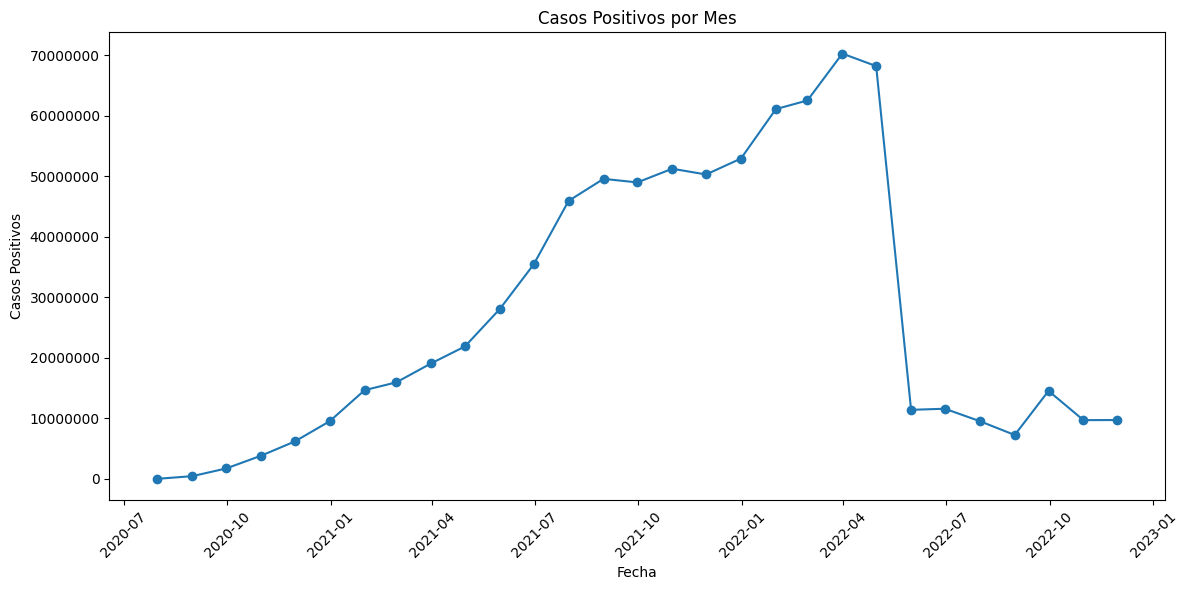

In [67]:
plt.figure(figsize=(12,6))
plt.plot(df_mes["Fecha"], df_mes["Positivas"], marker="o")

plt.title("Casos Positivos por Mes")
plt.xlabel("Fecha")
plt.ylabel("Casos Positivos")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

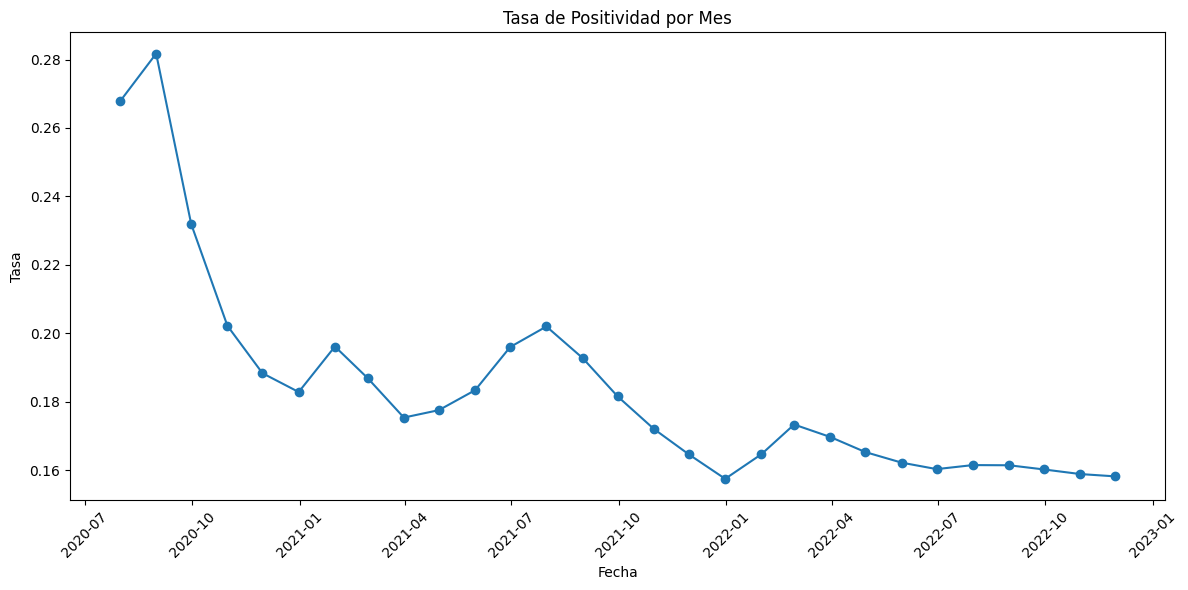

In [52]:
plt.figure(figsize=(12,6))
plt.plot(df_mes["Fecha"], df_mes["Tasa_Positividad"], marker="o")

plt.title("Tasa de Positividad por Mes")
plt.xlabel("Fecha")
plt.ylabel("Tasa")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

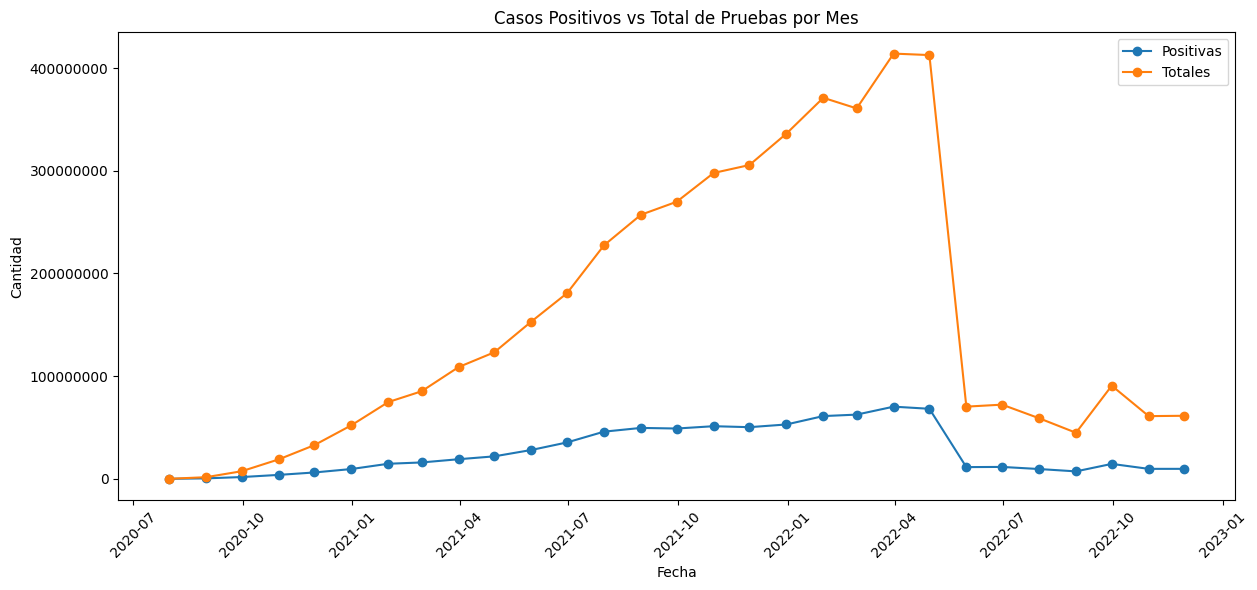

In [68]:
df_mes = df.resample("ME", on="Fecha").sum().reset_index()

plt.figure(figsize=(12,6))

plt.plot(df_mes["Fecha"], df_mes["Positivas"], marker="o", label="Positivas")
plt.plot(df_mes["Fecha"], df_mes["Total"], marker="o", label="Totales")

plt.title("Casos Positivos vs Total de Pruebas por Mes")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [ ]:
## Analisis Climatico con OpenWeather



#Peticion para acceder a la API
url = "https://api.openweathermap.org/data/2.5/weather?q=London,uk&APPID=54bf82adf3db85f9ffc7a56a0a0bef15"

respuesta = request.get(url, timeout = 5)
datos = respuesta.json() #Permite leer los datos de la API
print(datos)

In [72]:
print(datos.keys()) #Se revisan cuales son las llaves primarias

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])


In [73]:
#Se decide trabajar con la llave "main" y graficar las diferentes temperaturas
main = datos.get("main", {})
print(main.keys())

dict_keys(['temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'sea_level', 'grnd_level'])


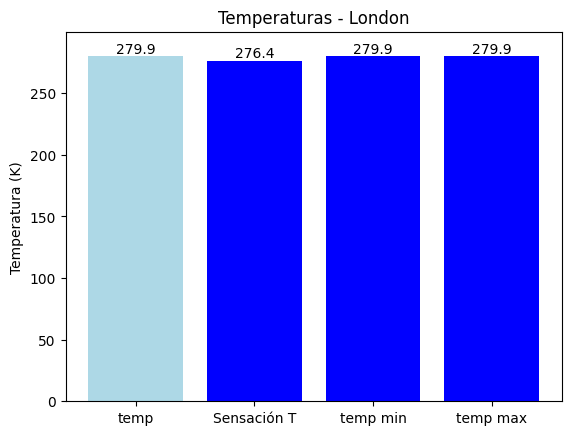

In [76]:
temps = [main['temp'], main['feels_like'], main['temp_min'], main['temp_max']]
labels = ["temp", "Sensación T", "temp min", "temp max"]

colors = ["lightblue", "blue", "blue", "blue"]

plt.figure()
bars = plt.bar(labels, temps, color=colors)
plt.ylabel("Temperatura (K)")
plt.ylim(0, max(temps) + 20)

# valores encima de cada barra
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}",
             ha='center', va='bottom')

plt.title("Temperaturas - London")
plt.show()

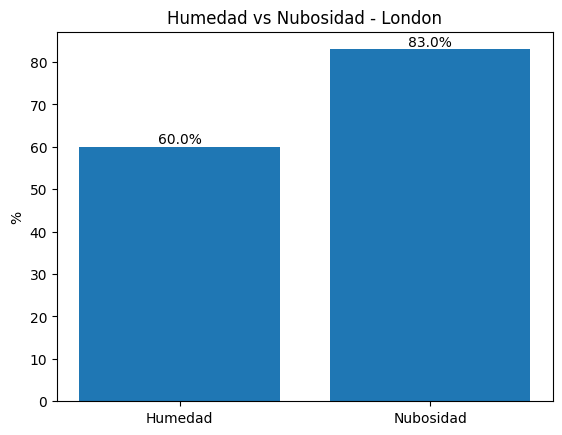

In [78]:
valores = [main["humidity"], clouds["all"]]
labels = ["Humedad", "Nubosidad"]

plt.figure()
bars = plt.bar(labels, valores)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha='center',
        va='bottom'
    )

plt.title("Humedad vs Nubosidad - London")
plt.ylabel("%")
plt.show()